In [19]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from scipy.stats import norm

sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [5]:
repo_folder = Path("../..")
data_folder = repo_folder / "data" / "6_CRM"
figure_folder = repo_folder / "Figures" / "6_CRM"
figure_folder.mkdir(parents=True, exist_ok=True)

# Extract V max parameters

In [332]:
gp_folder = repo_folder / "data" / "1_growth_phenotyping"
fn_growth_data = gp_folder / "fitted_growth_parameters.csv"
df_growth = pd.read_csv(fn_growth_data, index_col=0)



Fitted log-normal parameters for max growth rate: shape (sigma) = 0.91, scale = 0.13
0


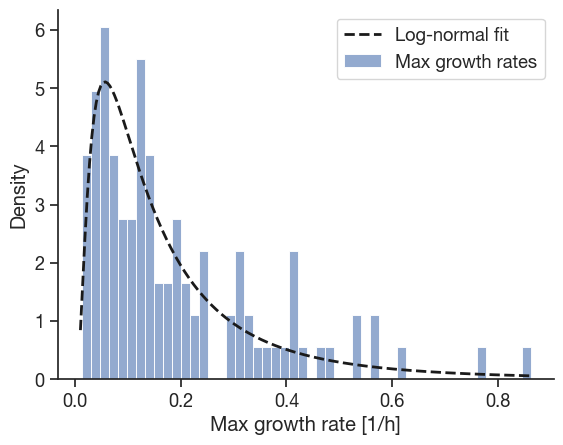

In [390]:
idx = df_growth['max_growth_rate'] > 0
growth_rates = df_growth.loc[idx, 'max_growth_rate']
uptake_rates = 10 * growth_rates  # Assume a yield of 0.1 gDW/mmol substrate

fit = st.lognorm.fit(growth_rates, floc=0) #floc=0 - No negative values
# fit = st.gamma.fit(df_growth.loc[idx, 'max_growth_rate'], floc=0)
shape, loc, scale = fit
sns.histplot(x = growth_rates, bins=50, stat='density', alpha=0.6, color='C0', edgecolor='w', label = 'Max growth rates')
x = np.linspace(0.01, growth_rates.max(), 200)
pdf = st.lognorm.pdf(x, shape, loc=loc, scale=scale)
plt.plot(x, pdf, 'k--', linewidth=2,  label = 'Log-normal fit')
plt.legend()
plt.xlabel('Max growth rate [1/h]')
plt.ylabel('Density')
sns.despine()
plt.savefig(figure_folder / "max_growth_rate_distribution.pdf", bbox_inches='tight')
print(f"Fitted log-normal parameters for max growth rate: shape (sigma) = {shape:.2f}, scale = {scale:.2f}")
print(loc)

Fitted log-normal parameters for uptake rates (from fixed yield) = 0.91, scale = 1.44
0


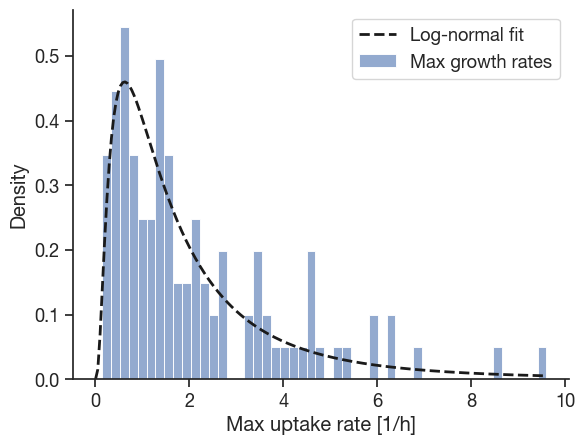

In [456]:
idx = df_growth['max_growth_rate'] > 0
growth_rates = df_growth.loc[idx, 'max_growth_rate']
g = 0.1
l = 0.1
uptake_rates =  growth_rates/(g*(1-l))  # Assume a yield of 0.1 gDW/mmol substrate

fit = st.lognorm.fit(uptake_rates, floc=0) #floc=0 - No negative values
# fit = st.gamma.fit(df_growth.loc[idx, 'max_growth_rate'], floc=0)
shape, loc, scale = fit
sns.histplot(x = uptake_rates, bins=50, stat='density', alpha=0.6, color='C0', edgecolor='w', label = 'Max growth rates')
x = np.linspace(0.01, uptake_rates.max(), 200)
pdf = st.lognorm.pdf(x, shape, loc=loc, scale=scale)
plt.plot(x, pdf, 'k--', linewidth=2,  label = 'Log-normal fit')
plt.legend()
plt.xlabel('Max uptake rate [1/h]')
plt.ylabel('Density')
sns.despine()
plt.savefig(figure_folder / "max_growth_rate_distribution.pdf", bbox_inches='tight')
print(f"Fitted log-normal parameters for uptake rates (from fixed yield) = {shape:.2f}, scale = {scale:.2f}")
print(loc)


In [461]:

print('sigma ', np.log(uptake_rates).std(), shape)
print('scale ', np.exp(np.log(uptake_rates).mean()), 'mu ', np.log(uptake_rates).mean())

sigma  0.916493570521607 0.9122008369901362
scale  1.4419742880506672 mu  0.3660132079483557


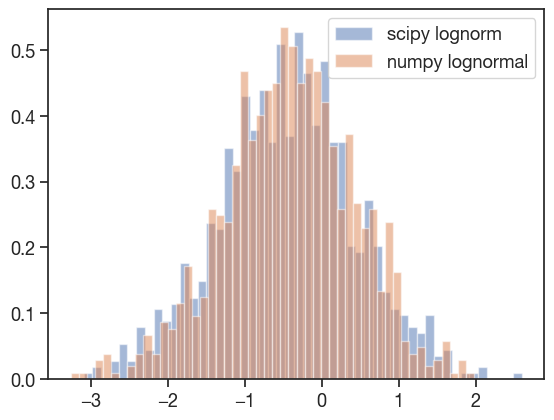

In [558]:
sps  = st.lognorm.rvs(2, loc = 0, scale = np.exp(-1), size=1000)
nps = np.random.lognormal(mean = -1, sigma = 2, size=1000)
plt.hist(np.log10(sps), bins=50, alpha=0.5, label='scipy lognorm', density=True)
plt.hist(np.log10(nps), bins=50, alpha=0.5, label='numpy lognormal', density=True)
plt.legend()


In [565]:
np.log10(np.exp(2))

np.float64(0.8685889638065036)

In [562]:
np.log10(sps).std(), np.log10(nps).std()

(np.float64(0.8880796867136894), np.float64(0.8438207868264064))

# Testing other estimates of release fractions

In [ ]:
# Get disitrbution of rates from Sulheim et al., 2025
fn = data_folder / "sulheim_2025_rates.csv"
df = pd.read_csv(fn, index_col=0)

In [ ]:
df['log10(Rate [mmol/gDW/h])'] = np.log10(df['Rate [mmol/gDW/h]'])
df['log(Rate [mmol/gDW/h])'] = np.log(df['Rate [mmol/gDW/h]'])

/Users/snorre/miniconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/snorre/miniconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [468]:
np.linspace(1, 41, 16, dtype=int)
np.linspace(0.1, 2.0, 11, endpoint=True)

array([0.1 , 0.29, 0.48, 0.67, 0.86, 1.05, 1.24, 1.43, 1.62, 1.81, 2.  ])

In [ ]:
df.Dataset.unique()

array(['SINTEF-23', 'Paczia-12', 'Vila-23'], dtype=object)

In [ ]:
# Drop the data from Vila et al., where there is larger uncertainty associated with the rate estimates
idx = (df.Dataset != "Vila-23")&(df['log10(Rate [mmol/gDW/h])'].notna())#&(df.Species == 'E. coli')

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_50206/2118427411.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x, pdf, 'k--', linewidth=2, label=f'Normal fit\n$\mu$={mu:.2f}, $\sigma$={sigma:.2f}')
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_50206/2118427411.py:15: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(x, pdf, 'k--', linewidth=2, label=f'Normal fit\n$\mu$={mu:.2f}, $\sigma$={sigma:.2f}')


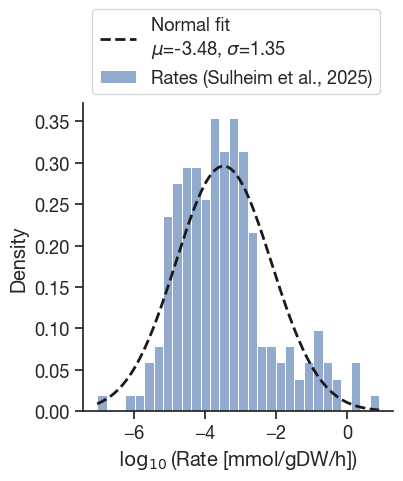

In [ ]:
log10_rates = df.loc[idx, 'log10(Rate [mmol/gDW/h])'].values
rates = df.loc[idx, 'Rate [mmol/gDW/h]'].values

# Fit lognormal
mu, sigma = st.norm.fit(log10_rates)

# Plot histogram of log10(rates)
fig, ax = plt.subplots(figsize=(4,4))
l = sns.histplot(x = log10_rates, bins=30, stat='density', alpha=0.6, color='C0', edgecolor='w', label='Rates (Sulheim et al., 2025)', ax = ax)

# Plot the fitted lognormal PDF in log10 space
# This is slightly complex, because we need to do a change of variables from x to log10(x)
x = np.linspace(log10_rates.min(), log10_rates.max(), 200)
pdf = norm.pdf(x, mu, sigma)
ax.plot(x, pdf, 'k--', linewidth=2, label=f'Normal fit\n$\mu$={mu:.2f}, $\sigma$={sigma:.2f}')

plt.legend()
plt.xlabel(r'$\log_{10}$(Rate [mmol/gDW/h])')
plt.ylabel('Density')
sns.move_legend(ax, "lower left", bbox_to_anchor= (0,1))
sns.despine()

plt.savefig(figure_folder / "sulheim_2025_rate_distribution.pdf", bbox_inches='tight')
plt.show()